# Week 1 Baseline Anomaly Test

## Goal
Build a simple baseline anomaly signal and test it on historical stock data.

## Signal
If a stock drops more than 3% in one day, buy it the next day and hold for one day.

## Why this matters
This gives me a first end-to-end pipeline for my AutoResearch project:
data -> signal -> backtest -> results.

In [2]:
!pip install yfinance pandas numpy matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 544.1 kB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 3.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.7/153.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 4.7 MB/s eta 0:00:00a 0:00:01
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15547 sha256=a31d3a294351b8f487fa4bcc4452b26e2bd732ec6ee2f5792fb086cd1518616c
  Stored in directory: /Users/jenniferjang/Library/Caches/pip/wheels/42/d6/84/bf57a755f4569494cd00de4bb46ef064874823f4d19c82e960
Successfully built multitasking
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstal

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]
start_date = "2022-01-01"
end_date = "2024-12-31"

In [27]:
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
close_prices = data["Close"].copy()
close_prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOGL,META,MSFT
Date,,,,,
2022-01-03,178.103668,170.404495,143.802963,335.904022,323.160767
2022-01-04,175.843231,167.522003,143.215820,333.909698,317.619537
2022-01-05,171.165833,164.356995,136.645599,321.645874,305.426727
2022-01-06,168.308487,163.253998,136.618332,329.871307,303.013336
2022-01-07,168.474869,162.554001,135.893829,329.206573,303.167755


In [29]:
daily_returns = close_prices.pct_change(). # percent changes
daily_returns.head()

Ticker,AAPL,AMZN,GOOGL,META,MSFT
Date,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.012692,-0.016916,-0.004083,-0.005937,-0.017147
2022-01-05,-0.026600,-0.018893,-0.045876,-0.036728,-0.038388
2022-01-06,-0.016693,-0.006711,-0.000200,0.025573,-0.007902
2022-01-07,0.000989,-0.004288,-0.005303,-0.002015,0.000510


In [8]:
signal = (daily_returns < -0.03).astype(int)  # 1: stock drop more than 0.03
signal.head()

Ticker,AAPL,AMZN,GOOGL,META,MSFT
Date,,,,,
2022-01-03,0,0,0,0,0
2022-01-04,0,0,0,0,0
2022-01-05,0,0,1,1,1
2022-01-06,0,0,0,0,0
2022-01-07,0,0,0,0,0


In [31]:
shifted_signal = signal.shift(1) # shift by 1
strategy_returns = shifted_signal * daily_returns # only earn returns on days when I decided to trade.
strategy_returns.head()

Ticker,AAPL,AMZN,GOOGL,META,MSFT
Date,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.0,-0.0,-0.0000,-0.000000,-0.000000
2022-01-05,-0.0,-0.0,-0.0000,-0.000000,-0.000000
2022-01-06,-0.0,-0.0,-0.0002,0.025573,-0.007902
2022-01-07,0.0,-0.0,-0.0000,-0.000000,0.000000


In [32]:
portfolio_returns = strategy_returns.sum(axis=1) / shifted_signal.sum(axis=1)
portfolio_returns = portfolio_returns.fillna(0)

In [33]:
cumulative_returns = (1 + portfolio_returns).cumprod()
cumulative_returns.head()

Date
2022-01-03    1.000000
2022-01-04    1.000000
2022-01-05    1.000000
2022-01-06    1.005824
2022-01-07    1.005824
dtype: float64

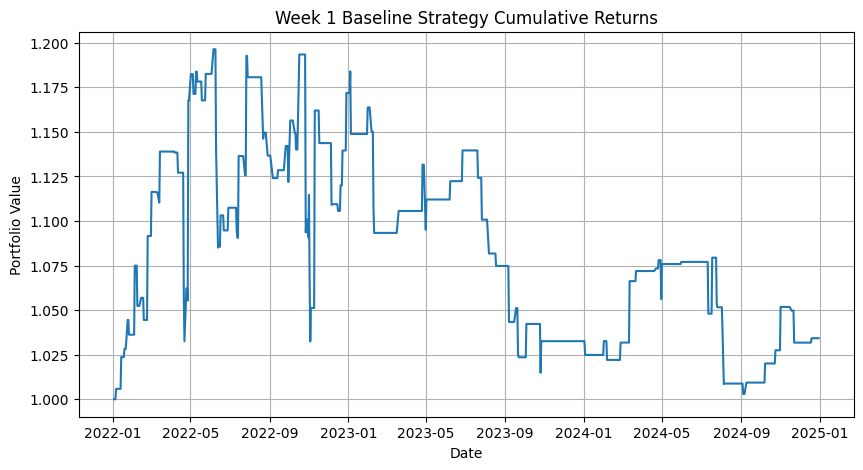

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(cumulative_returns)
plt.title("Week 1 Baseline Strategy Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

In [35]:
avg_daily_return = portfolio_returns.mean()
std_daily_return = portfolio_returns.std()
annualized_sharpe = (avg_daily_return / std_daily_return) * np.sqrt(252) if std_daily_return != 0 else np.nan
win_rate = (portfolio_returns > 0).mean()

rolling_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - rolling_max) / rolling_max
max_drawdown = drawdown.min()

print("Average Daily Return:", round(avg_daily_return, 6))
print("Annualized Sharpe Ratio:", round(annualized_sharpe, 3))
print("Win Rate:", round(win_rate, 3))
print("Max Drawdown:", round(max_drawdown, 3))

Average Daily Return: 9.7e-05
Annualized Sharpe Ratio: 0.15
Win Rate: 0.077
Max Drawdown: -0.162


In [36]:
results = pd.DataFrame({
    "Metric": ["Average Daily Return", "Annualized Sharpe Ratio", "Win Rate", "Max Drawdown"],
    "Value": [avg_daily_return, annualized_sharpe, win_rate, max_drawdown]
})

results

,Metric,Value
0,Average Daily Return,0.000097
1,Annualized Sharpe Ratio,0.149662
2,Win Rate,0.077128
3,Max Drawdown,-0.161686
